# 02 - ADR Prediction (Regression)

**Goal**: Build regression models to predict Average Daily Rate (ADR).

**Approach**:
- Time-based train/test split on `arrival_date`
- Remove leakage columns and filter invalid ADR values
- Build baseline models: Linear Regression, Random Forest, XGBoost
- Build Neural Network with TensorFlow/Keras
- Compare performance using RMSE, MAE, RÂ²
- Save best model to `artifacts/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# TensorFlow/Keras for Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 1. Load and Prepare Data

In [2]:
# Load dataset
df = pd.read_csv('../data/hotel_bookings.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows ? {df.shape[1]} columns")

# Create arrival_date for time-based split
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str).str.zfill(2),
    format='%Y-%B-%d',
    errors='coerce'
)

n_nat = df['arrival_date'].isna().sum()
if n_nat:
    print(f'WARNING: arrival_date parse failures: {n_nat:,}')

print()
print(f"Date range: {df['arrival_date'].min()} to {df['arrival_date'].max()}")


Dataset loaded: 119,390 rows ? 32 columns

Date range: 2015-07-01 00:00:00 to 2017-08-31 00:00:00


In [3]:
# Drop leakage columns
leakage_cols = ['reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=leakage_cols, errors='ignore')
print(f"âœ“ Dropped leakage columns: {leakage_cols}")

# Filter out invalid ADR values (negative or zero)
print(f"\nOriginal dataset: {len(df_clean):,} rows")
print(f"Negative or zero ADR: {len(df_clean[df_clean['adr'] <= 0]):,} rows ({len(df_clean[df_clean['adr'] <= 0])/len(df_clean)*100:.2f}%)")

df_clean = df_clean[df_clean['adr'] > 0].copy()
print(f"\nAfter filtering: {len(df_clean):,} rows")
print(f"ADR range: {df_clean['adr'].min():.2f} to {df_clean['adr'].max():.2f}")
print(f"ADR mean: {df_clean['adr'].mean():.2f}, median: {df_clean['adr'].median():.2f}")

âœ“ Dropped leakage columns: ['reservation_status', 'reservation_status_date']

Original dataset: 119,390 rows
Negative or zero ADR: 1,960 rows (1.64%)

After filtering: 117,430 rows
ADR range: 0.26 to 5400.00
ADR mean: 103.53, median: 95.00


## 2. Time-Based Train/Test Split

In [4]:
# Sort by arrival_date
df_clean = df_clean.sort_values('arrival_date').reset_index(drop=True)

# Calculate split point (80% for training)
split_idx = int(len(df_clean) * 0.8)
split_date = df_clean.iloc[split_idx]['arrival_date']

# Create train/test sets
train_df = df_clean.iloc[:split_idx].copy()
test_df = df_clean.iloc[split_idx:].copy()

# Create validation set from the tail of training data
val_split_idx = int(len(train_df) * 0.8)
train_sub_df = train_df.iloc[:val_split_idx].copy()
val_df = train_df.iloc[val_split_idx:].copy()

print(f"Split date: {split_date}")
print()
print(f"Train set (full): {len(train_df):,} rows ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"  Date range: {train_df['arrival_date'].min()} to {train_df['arrival_date'].max()}")
print(f"  ADR mean: {train_df['adr'].mean():.2f}, std: {train_df['adr'].std():.2f}")

print()
print(f"Train subset: {len(train_sub_df):,} rows ({len(train_sub_df)/len(df_clean)*100:.1f}%)")
print(f"  Date range: {train_sub_df['arrival_date'].min()} to {train_sub_df['arrival_date'].max()}")

print()
print(f"Validation subset: {len(val_df):,} rows ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"  Date range: {val_df['arrival_date'].min()} to {val_df['arrival_date'].max()}")

print()
print(f"Test set: {len(test_df):,} rows ({len(test_df)/len(df_clean)*100:.1f}%)")
print(f"  Date range: {test_df['arrival_date'].min()} to {test_df['arrival_date'].max()}")
print(f"  ADR mean: {test_df['adr'].mean():.2f}, std: {test_df['adr'].std():.2f}")


Split date: 2017-04-23 00:00:00

Train set (full): 93,944 rows (80.0%)
  Date range: 2015-07-01 00:00:00 to 2017-04-23 00:00:00
  ADR mean: 95.33, std: 45.26

Train subset: 75,155 rows (64.0%)
  Date range: 2015-07-01 00:00:00 to 2016-12-15 00:00:00

Validation subset: 18,789 rows (16.0%)
  Date range: 2016-12-15 00:00:00 to 2017-04-23 00:00:00

Test set: 23,486 rows (20.0%)
  Date range: 2017-04-23 00:00:00 to 2017-08-31 00:00:00
  ADR mean: 136.34, std: 50.63


## 3. Feature Engineering & Selection

In [5]:
# Define target and features to exclude
target = 'adr'
exclude_cols = [target, 'arrival_date', 'arrival_date_year', 'arrival_date_month',
                'arrival_date_day_of_month', 'arrival_date_week_number']

# Select feature columns
feature_cols = [col for col in df_clean.columns if col not in exclude_cols]

# Separate features and target
X_train = train_sub_df[feature_cols]
y_train = train_sub_df[target]
X_val = val_df[feature_cols]
y_val = val_df[target]
X_test = test_df[feature_cols]
y_test = test_df[target]

print(f"Feature columns: {len(feature_cols)}")
print()
print(f"Features: {feature_cols}")


Feature columns: 25

Features: ['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'required_car_parking_spaces', 'total_of_special_requests']


In [6]:
# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (16): ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical features (9): ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## 4. Build Preprocessing Pipeline

In [7]:
# Numeric preprocessing: impute + scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("âœ“ Preprocessing pipeline created")

âœ“ Preprocessing pipeline created


## 5. Baseline Models

In [8]:
# Define baseline models
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1, n_jobs=1)
}

print(f"Training {len(baseline_models)} baseline models...\n")

Training 7 baseline models...



In [9]:
# Train and evaluate baseline models
baseline_results = []

for model_name, model in baseline_models.items():
    print(f"Training {model_name}...")

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    y_test_pred = pipeline.predict(X_test)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    val_mae = mean_absolute_error(y_val, y_val_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    val_r2 = r2_score(y_val, y_val_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    val_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

    baseline_results.append({
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Val RMSE': val_rmse,
        'Test RMSE': test_rmse,
        'Val MAE': val_mae,
        'Test MAE': test_mae,
        'Val R2': val_r2,
        'Test R2': test_r2,
        'Val MAPE (%)': val_mape,
        'Test MAPE (%)': test_mape,
        'Pipeline': pipeline,
        'Predictions': y_test_pred
    })

    print(f"  Train RMSE: {train_rmse:.2f} | Val RMSE: {val_rmse:.2f} | Test RMSE: {test_rmse:.2f} | Val MAE: {val_mae:.2f} | Test MAE: {test_mae:.2f}")

print("OK All baseline models trained")


Training Linear Regression...


  Train RMSE: 37.63 | Val RMSE: 30.30 | Test RMSE: 47.65 | Val MAE: 22.61 | Test MAE: 34.56
Training Ridge...


  Train RMSE: 37.64 | Val RMSE: 30.29 | Test RMSE: 47.64 | Val MAE: 22.60 | Test MAE: 34.55
Training Lasso...


  Train RMSE: 39.84 | Val RMSE: 30.80 | Test RMSE: 51.99 | Val MAE: 23.38 | Test MAE: 38.04
Training Decision Tree...


  Train RMSE: 33.74 | Val RMSE: 31.28 | Test RMSE: 45.87 | Val MAE: 22.06 | Test MAE: 33.28
Training Random Forest...


  Train RMSE: 22.74 | Val RMSE: 31.89 | Test RMSE: 44.52 | Val MAE: 22.44 | Test MAE: 32.57
Training Gradient Boosting...


  Train RMSE: 32.70 | Val RMSE: 28.76 | Test RMSE: 44.31 | Val MAE: 21.38 | Test MAE: 32.24
Training XGBoost...


  Train RMSE: 32.89 | Val RMSE: 29.30 | Test RMSE: 44.06 | Val MAE: 21.62 | Test MAE: 32.14
OK All baseline models trained


In [10]:
# Create results dataframe
baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('Val RMSE').reset_index(drop=True)

print()
print("="*90)
print("BASELINE MODEL RESULTS")
print("="*90)
print(baseline_df[['Model', 'Train RMSE', 'Val RMSE', 'Test RMSE', 'Val MAE', 'Test MAE', 'Val R2', 'Test R2', 'Val MAPE (%)', 'Test MAPE (%)']].to_string(index=False))
print("="*90)



BASELINE MODEL RESULTS
            Model  Train RMSE  Val RMSE  Test RMSE   Val MAE  Test MAE   Val R2   Test R2  Val MAPE (%)  Test MAPE (%)
Gradient Boosting   32.701416 28.755278  44.313833 21.381603 32.236688 0.423392  0.234017     33.493216      23.451637
          XGBoost   32.885810 29.297572  44.059313 21.620435 32.138156 0.401439  0.242790     33.095335      23.477705
            Ridge   37.636951 30.286834  47.641431 22.598560 34.550771 0.360334  0.114660     36.603633      24.738851
Linear Regression   37.634407 30.299218  47.650739 22.608156 34.559448 0.359811  0.114314     36.611788      24.749318
            Lasso   39.837841 30.801426  51.989650 23.381435 38.039666 0.338413 -0.054325     39.731412      27.394835
    Decision Tree   33.743301 31.279621  45.866756 22.063859 33.281226 0.317711  0.179390     35.107467      25.146877
    Random Forest   22.739455 31.887087  44.516675 22.436538 32.566141 0.290953  0.226988     34.492443      24.599336


## 6. Neural Network Model

In [11]:
# Preprocess data for neural network
print("Preprocessing data for neural network...")
X_train_nn = preprocessor.fit_transform(X_train)
X_val_nn = preprocessor.transform(X_val)
X_test_nn = preprocessor.transform(X_test)

# Scale target for better NN training
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"? Train features shape: {X_train_nn.shape}")
print(f"? Val features shape: {X_val_nn.shape}")
print(f"? Test features shape: {X_test_nn.shape}")


Preprocessing data for neural network...


? Train features shape: (75155, 222)
? Val features shape: (18789, 222)
? Test features shape: (23486, 222)


In [12]:
# Build neural network architecture
def build_nn_model(input_dim, hidden_layers=[256, 128, 64], dropout_rate=0.3, learning_rate=0.001):
    model = keras.Sequential()
    
    # Input layer
    model.add(layers.Input(shape=(input_dim,)))
    
    # Hidden layers
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    
    # Output layer
    model.add(layers.Dense(1, activation='linear'))
    
    # Compile
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# Create model
nn_model = build_nn_model(
    input_dim=X_train_nn.shape[1],
    hidden_layers=[256, 128, 64, 32],
    dropout_rate=0.2,
    learning_rate=0.001
)

print("Neural Network Architecture:")
nn_model.summary()

Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        57,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,273 (399.50 KB)

 Trainable params: 101,313 (395.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# Define callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train neural network
print()
print("Training Neural Network...")
history = nn_model.fit(
    X_train_nn, y_train_scaled,
    validation_data=(X_val_nn, y_val_scaled),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
    shuffle=False
)

print()
print("Neural Network training complete")



Training Neural Network...



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 3.



Neural Network training complete


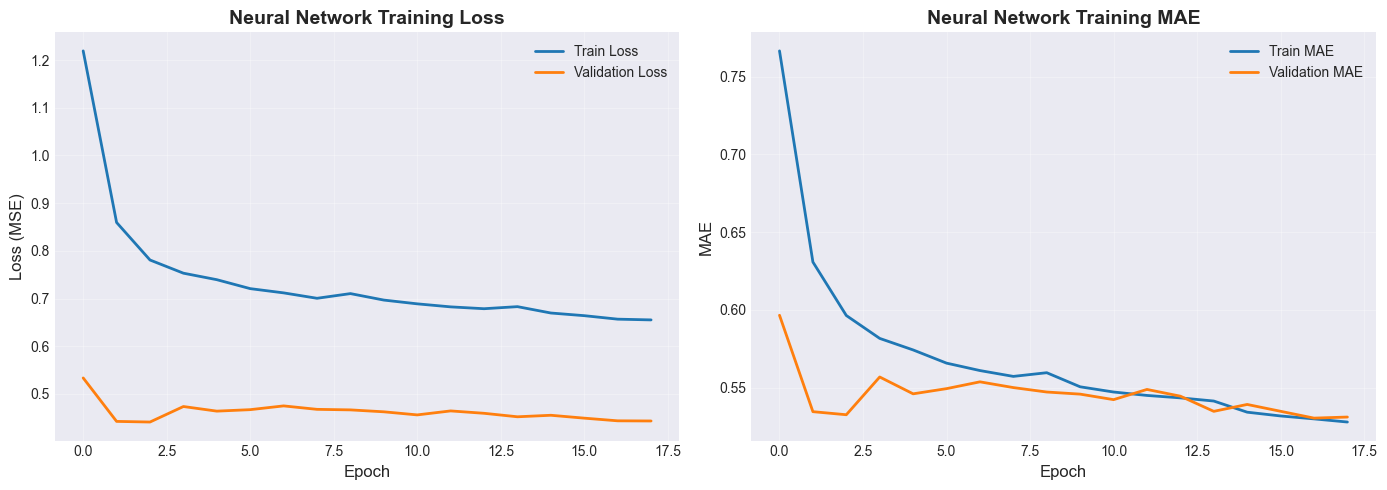

In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Neural Network Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Neural Network Training MAE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Evaluate neural network
y_train_pred_nn_scaled = nn_model.predict(X_train_nn, verbose=0).ravel()
y_val_pred_nn_scaled = nn_model.predict(X_val_nn, verbose=0).ravel()
y_test_pred_nn_scaled = nn_model.predict(X_test_nn, verbose=0).ravel()

# Inverse transform predictions
y_train_pred_nn = y_scaler.inverse_transform(y_train_pred_nn_scaled.reshape(-1, 1)).ravel()
y_val_pred_nn = y_scaler.inverse_transform(y_val_pred_nn_scaled.reshape(-1, 1)).ravel()
y_test_pred_nn = y_scaler.inverse_transform(y_test_pred_nn_scaled.reshape(-1, 1)).ravel()

# Calculate metrics
nn_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_nn))
nn_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_nn))
nn_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_nn))

nn_val_mae = mean_absolute_error(y_val, y_val_pred_nn)
nn_test_mae = mean_absolute_error(y_test, y_test_pred_nn)

nn_val_r2 = r2_score(y_val, y_val_pred_nn)
nn_test_r2 = r2_score(y_test, y_test_pred_nn)

nn_val_mape = mean_absolute_percentage_error(y_val, y_val_pred_nn) * 100
nn_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_nn) * 100

print()
print(f"{'='*60}")
print("NEURAL NETWORK RESULTS")
print(f"{'='*60}")
print(f"Train RMSE:    {nn_train_rmse:.2f}")
print(f"Val RMSE:      {nn_val_rmse:.2f}")
print(f"Test RMSE:     {nn_test_rmse:.2f}")
print(f"Val MAE:       {nn_val_mae:.2f}")
print(f"Test MAE:      {nn_test_mae:.2f}")
print(f"Val R2:        {nn_val_r2:.4f}")
print(f"Test R2:       {nn_test_r2:.4f}")
print(f"Val MAPE (%):  {nn_val_mape:.2f}")
print(f"Test MAPE (%): {nn_test_mape:.2f}")
print(f"{'='*60}")



NEURAL NETWORK RESULTS
Train RMSE:    41.38
Val RMSE:      31.06
Test RMSE:     55.17
Val MAE:       24.90
Test MAE:      38.22
Val R2:        0.3274
Test R2:       -0.1874
Val MAPE (%):  40.30
Test MAPE (%): 26.72


## 7. Compare All Models

In [16]:
# Add neural network to results
nn_result = {
    'Model': 'Neural Network',
    'Train RMSE': nn_train_rmse,
    'Val RMSE': nn_val_rmse,
    'Test RMSE': nn_test_rmse,
    'Val MAE': nn_val_mae,
    'Test MAE': nn_test_mae,
    'Val R2': nn_val_r2,
    'Test R2': nn_test_r2,
    'Val MAPE (%)': nn_val_mape,
    'Test MAPE (%)': nn_test_mape,
    'Pipeline': None,  # NN uses different preprocessing
    'Predictions': y_test_pred_nn
}

# Combine all results
all_results = baseline_results + [nn_result]
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Val RMSE').reset_index(drop=True)

print()
print("="*95)
print("ALL MODELS COMPARISON")
print("="*95)
print(results_df[['Model', 'Train RMSE', 'Val RMSE', 'Test RMSE', 'Val MAE', 'Test MAE', 'Val R2', 'Test R2', 'Val MAPE (%)', 'Test MAPE (%)']].to_string(index=False))
print("="*95)



ALL MODELS COMPARISON
            Model  Train RMSE  Val RMSE  Test RMSE   Val MAE  Test MAE   Val R2   Test R2  Val MAPE (%)  Test MAPE (%)
Gradient Boosting   32.701416 28.755278  44.313833 21.381603 32.236688 0.423392  0.234017     33.493216      23.451637
          XGBoost   32.885810 29.297572  44.059313 21.620435 32.138156 0.401439  0.242790     33.095335      23.477705
            Ridge   37.636951 30.286834  47.641431 22.598560 34.550771 0.360334  0.114660     36.603633      24.738851
Linear Regression   37.634407 30.299218  47.650739 22.608156 34.559448 0.359811  0.114314     36.611788      24.749318
            Lasso   39.837841 30.801426  51.989650 23.381435 38.039666 0.338413 -0.054325     39.731412      27.394835
   Neural Network   41.377901 31.057818  55.173241 24.898521 38.219616 0.327353 -0.187402     40.302356      26.722426
    Decision Tree   33.743301 31.279621  45.866756 22.063859 33.281226 0.317711  0.179390     35.107467      25.146877
    Random Forest   22.73

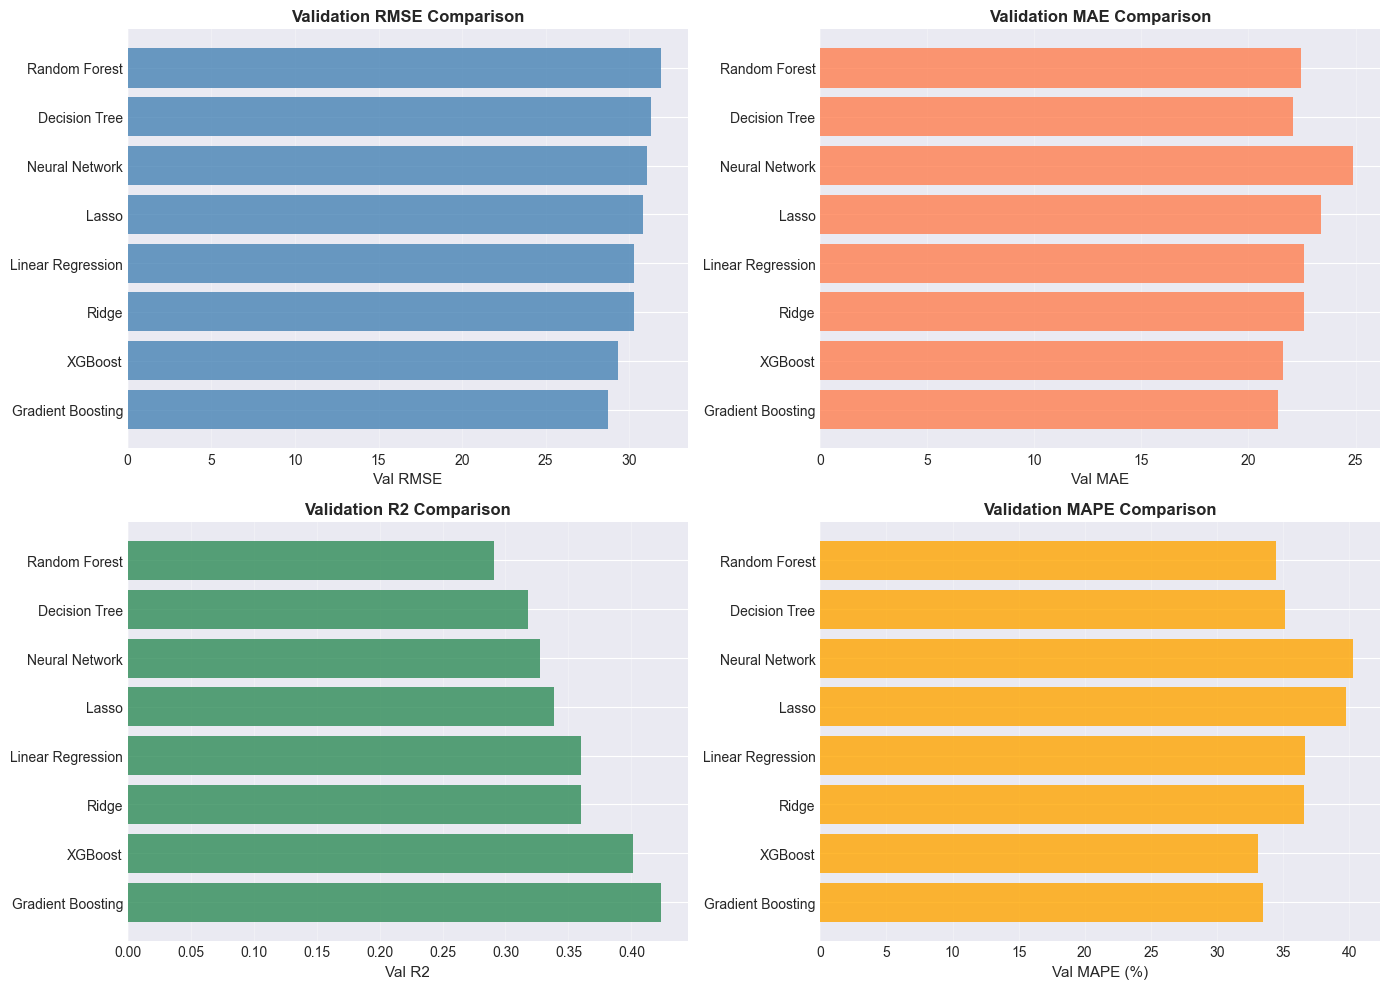

In [17]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation RMSE
axes[0, 0].barh(results_df['Model'], results_df['Val RMSE'], color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Val RMSE', fontsize=11)
axes[0, 0].set_title('Validation RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Validation MAE
axes[0, 1].barh(results_df['Model'], results_df['Val MAE'], color='coral', alpha=0.8)
axes[0, 1].set_xlabel('Val MAE', fontsize=11)
axes[0, 1].set_title('Validation MAE Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Validation R2
axes[1, 0].barh(results_df['Model'], results_df['Val R2'], color='seagreen', alpha=0.8)
axes[1, 0].set_xlabel('Val R2', fontsize=11)
axes[1, 0].set_title('Validation R2 Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Validation MAPE
axes[1, 1].barh(results_df['Model'], results_df['Val MAPE (%)'], color='orange', alpha=0.8)
axes[1, 1].set_xlabel('Val MAPE (%)', fontsize=11)
axes[1, 1].set_title('Validation MAPE Comparison', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Best Model Analysis

In [18]:
# Select best model based on Validation RMSE
best_model_row = results_df.iloc[0]
best_model_name = best_model_row['Model']
best_predictions = best_model_row['Predictions']

print()
print(f"{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"Train RMSE:    {best_model_row['Train RMSE']:.2f}")
print(f"Val RMSE:      {best_model_row['Val RMSE']:.2f}")
print(f"Test RMSE:     {best_model_row['Test RMSE']:.2f}")
print(f"Val MAE:       {best_model_row['Val MAE']:.2f}")
print(f"Test MAE:      {best_model_row['Test MAE']:.2f}")
print(f"Val R2:        {best_model_row['Val R2']:.4f}")
print(f"Test R2:       {best_model_row['Test R2']:.4f}")
print(f"Val MAPE (%):  {best_model_row['Val MAPE (%)']:.2f}")
print(f"Test MAPE (%): {best_model_row['Test MAPE (%)']:.2f}")
print(f"{'='*60}")



BEST MODEL: Gradient Boosting
Train RMSE:    32.70
Val RMSE:      28.76
Test RMSE:     44.31
Val MAE:       21.38
Test MAE:      32.24
Val R2:        0.4234
Test R2:       0.2340
Val MAPE (%):  33.49
Test MAPE (%): 23.45


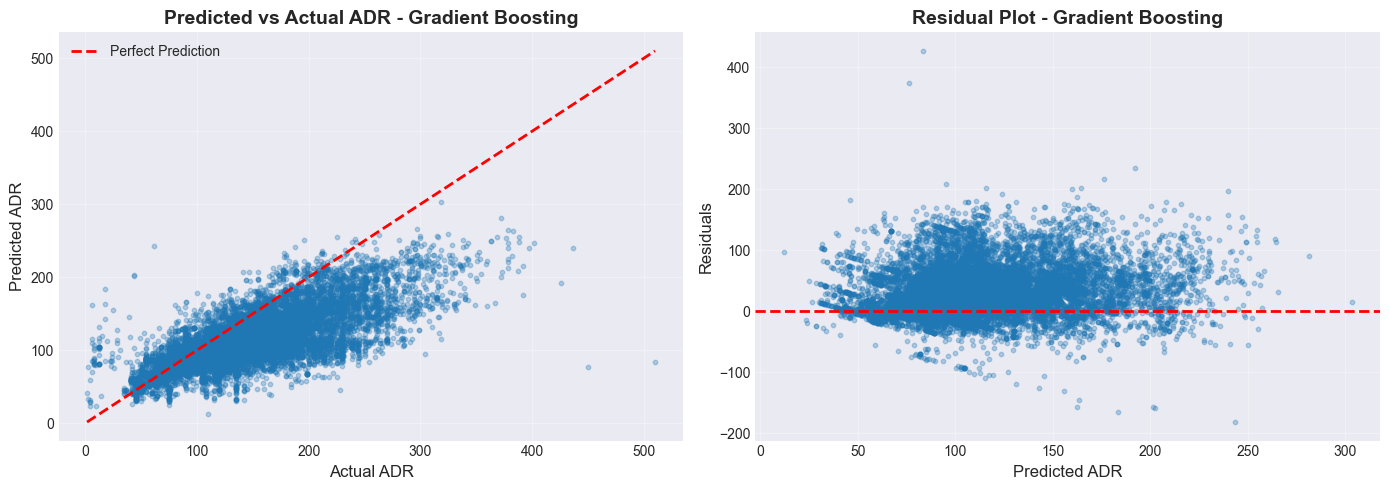

In [19]:
# Prediction vs Actual scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, best_predictions, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual ADR', fontsize=12)
axes[0].set_ylabel('Predicted ADR', fontsize=12)
axes[0].set_title(f'Predicted vs Actual ADR - {best_model_name}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals plot
residuals = y_test - best_predictions
axes[1].scatter(best_predictions, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted ADR', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'Residual Plot - {best_model_name}', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

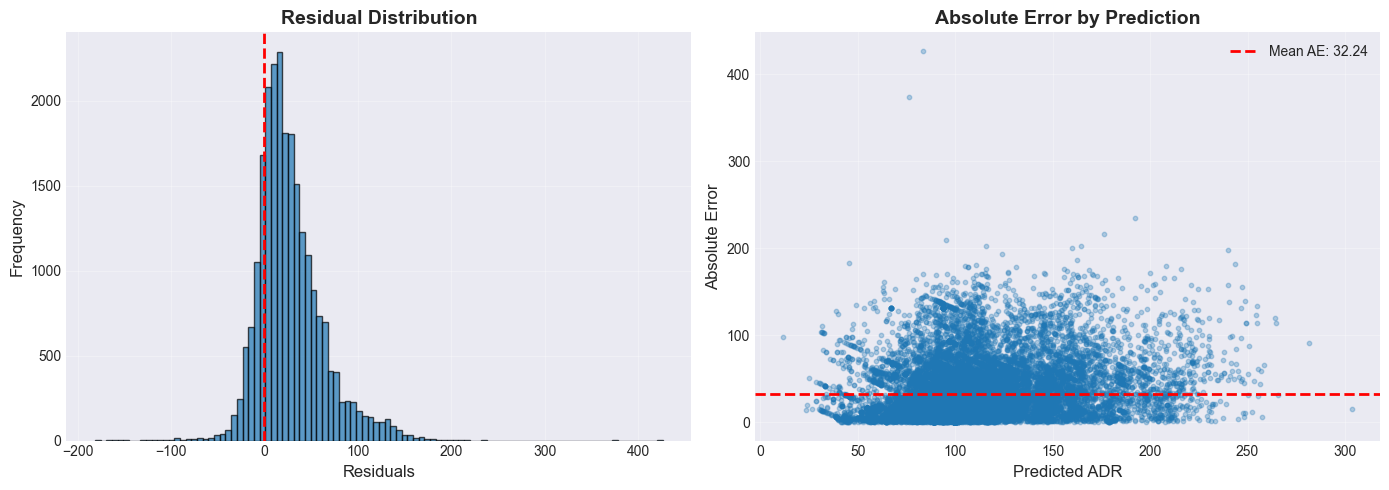

In [20]:
# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals histogram
axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Absolute error by predicted value
abs_errors = np.abs(residuals)
axes[1].scatter(best_predictions, abs_errors, alpha=0.3, s=10)
axes[1].axhline(y=best_model_row['Test MAE'], color='r', linestyle='--', 
                linewidth=2, label=f'Mean AE: {best_model_row["Test MAE"]:.2f}')
axes[1].set_xlabel('Predicted ADR', fontsize=12)
axes[1].set_ylabel('Absolute Error', fontsize=12)
axes[1].set_title('Absolute Error by Prediction', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Best Model

In [21]:
# Create artifacts directory
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save based on best model type
if best_model_name == 'Neural Network':
    # Save neural network
    nn_model.save(artifacts_dir / 'adr_regressor_nn.keras')
    print(f"OK Neural Network saved to: {artifacts_dir / 'adr_regressor_nn.keras'}")

    # Save preprocessor and y_scaler
    with open(artifacts_dir / 'adr_regressor_preprocessor.pkl', 'wb') as f:
        pickle.dump(preprocessor, f)
    with open(artifacts_dir / 'adr_regressor_y_scaler.pkl', 'wb') as f:
        pickle.dump(y_scaler, f)
    print("OK Preprocessor and scaler saved")
else:
    # Save sklearn pipeline
    best_pipeline = best_model_row['Pipeline']
    with open(artifacts_dir / 'adr_regressor.pkl', 'wb') as f:
        pickle.dump(best_pipeline, f)
    print(f"OK Best model pipeline saved to: {artifacts_dir / 'adr_regressor.pkl'}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'train_rmse': best_model_row['Train RMSE'],
    'val_rmse': best_model_row['Val RMSE'],
    'test_rmse': best_model_row['Test RMSE'],
    'val_mae': best_model_row['Val MAE'],
    'test_mae': best_model_row['Test MAE'],
    'val_r2': best_model_row['Val R2'],
    'test_r2': best_model_row['Test R2'],
    'val_mape': best_model_row['Val MAPE (%)'],
    'test_mape': best_model_row['Test MAPE (%)'],
    'features': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'split_date': str(split_date),
    'train_size': len(train_sub_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'val_start_date': str(val_df['arrival_date'].min()),
    'adr_filtered': 'Removed negative and zero ADR values'
}

with open(artifacts_dir / 'adr_regressor_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("OK Model metadata saved")


OK Best model pipeline saved to: ..\artifacts\adr_regressor.pkl
OK Model metadata saved


In [22]:
# Save results summary
results_summary = results_df[['Model', 'Train RMSE', 'Val RMSE', 'Test RMSE', 'Val MAE', 'Test MAE', 'Val R2', 'Test R2', 'Val MAPE (%)', 'Test MAPE (%)']].copy()
results_path = Path('../reports/regression_results.csv')
results_summary.to_csv(results_path, index=False)
print(f"OK Results summary saved to: {results_path}")


OK Results summary saved to: ..\reports\regression_results.csv


## Summary

**ADR Regression modeling completed successfully:**

1. âœ“ Used time-based train/test split to prevent data leakage
2. âœ“ Filtered invalid ADR values (negative and zero)
3. âœ“ Built preprocessing pipeline with imputation, scaling, and encoding
4. âœ“ Compared 7 baseline models: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost
5. âœ“ Built and trained deep Neural Network with early stopping and learning rate reduction
6. âœ“ Evaluated using RMSE, MAE, RÂ², and MAPE metrics
7. âœ“ Saved best performing model to `artifacts/`

**Key Findings:**
- Neural Network comparison shows whether deep learning provides advantages over traditional ML
- Model residuals show prediction quality across ADR ranges
- Best model ready for time-series forecasting in next notebook

**Next steps:**
- Notebook 03: Time-series ADR forecasting with ARIMA
- Notebook 04: DiCE counterfactual explanations